# Sleep Stage Classification Notebook

This notebook mirrors the workflow in `final_proj.py`.

In [1]:
!pip install mne
!pip install yasa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 41.5 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.8/33.8 MB 50.1 MB/s eta 0:00:00


In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import numpy as np
import mne
import pandas as pd
from yasa import Hypnogram
from pathlib import Path

## RON DID THESE IMPORTS

import lightgbm as lgb

from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

import xgboost as xgb

from xgboost import XGBClassifier


## Data Loading -
We used 3 nights of both healthy and sypmotatic indivduals. Our test sets included a full night of an indivdual not in the training set.

In [3]:
# Create raw object from PSG edf data
# raw has diff channels, number of time points, time points, and duration of the data
# ch_names, n_times, times, duration
# Two EEG channels that will be our main data to determine sleep stages
# One EOG and one EMG useful for identifying REM sleep
# --------------------------------------------------EXCLUDE---------------------------------------------------------------
# Resp oro-nasal is used to identify sleep apneas and hypopneas
# temp rectal is body temp useful for identifying sleep quality and sleep onset (wake to sleep)
# Event markers is specific to how each study was ran I think

## Created a variable for the project destination since it will be different for everyone
project_destination = Path.cwd()

# SC Files (Healthy)
raw1 = mne.io.read_raw_edf(f'{project_destination}/SC4001E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw1.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})
raw2 = mne.io.read_raw_edf(f'{project_destination}/SC4161E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw2.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw3 = mne.io.read_raw_edf(f'{project_destination}/SC4011E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw3.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})


# ST Files (Symptomatic)
raw_st1 = mne.io.read_raw_edf(f'{project_destination}/ST7011J0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw_st1.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw_st2 = mne.io.read_raw_edf(f'{project_destination}/ST7012J0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw_st2.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw_st3 = mne.io.read_raw_edf(f'{project_destination}/ST7122J0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw_st3.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

## Testing data not used for training the model, just to see how it performs on new data
# SC Test
test_raw1 = mne.io.read_raw_edf(f'{project_destination}/SC4311E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
test_raw1.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

# ST Test
test_raw2 = mne.io.read_raw_edf(f'{project_destination}/ST7222J0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
test_raw2.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

Extracting EDF parameters from /content/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/SC4161E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/SC4011E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/ST7011J0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/ST7012J0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/ST7122J0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/SC4311E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/ST7222J0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


<RawEDF | ST7222J0-PSG.edf, 5 x 2874000 (28740.0 s), ~9 KiB, data not loaded>

## Annotations

In [6]:
# the hypnogram.edf file only has annotations, must add to raw data
ann1 = mne.read_annotations(f'{project_destination}/SC4001EC-Hypnogram.edf')
raw1.set_annotations(ann1)

ann2 = mne.read_annotations(f'{project_destination}/SC4161EC-Hypnogram.edf')
raw2.set_annotations(ann2)

ann3 = mne.read_annotations(f'{project_destination}/SC4011EH-Hypnogram.edf')
raw3.set_annotations(ann3)


ann_st1 = mne.read_annotations(f'{project_destination}/ST7011JP-Hypnogram.edf')
raw_st1.set_annotations(ann_st1)

ann_st2 = mne.read_annotations(f'{project_destination}/ST7011JP-Hypnogram.edf')
raw_st2.set_annotations(ann_st2)

ann_st3 = mne.read_annotations(f'{project_destination}/ST7122JE-Hypnogram.edf')
raw_st3.set_annotations(ann_st3)


## For the test data
test_ann1 = mne.read_annotations(f'{project_destination}/SC4311EC-Hypnogram.edf')
test_raw1.set_annotations(test_ann1)

test_ann2 = mne.read_annotations(f'{project_destination}/ST7222JA-Hypnogram.edf')
test_raw2.set_annotations(test_ann2)

# Pick common channels to avoid nchan mismatch error during concatenation
common_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']
raws_to_concat = [raw1, raw2, raw3, raw_st1 , raw_st2, raw_st3]
for r in raws_to_concat:
    r.pick(common_channels)

raw = mne.concatenate_raws(raws_to_concat) # Data used to train the model
raw.resample(100.0, npad='auto')  # lower sampling rate before epoching to speed processing

# Epoch object has an (X,Y,Z) numpy matrix
# X: number of epochs (each epoch is 30 seconds as specified below)
# Y: number of channels (the EDF data has 4 channels)
# Z: data points in the 30 second intervals
epochs = mne.make_fixed_length_epochs(raw, duration=30.0, preload=True)

psd = epochs.compute_psd(fmin=0.5, fmax=30, picks=['eeg', 'eog', 'emg'])

Sampling frequency of the instance is already 100.0, returning unmodified.
Not setting metadata
11330 matching events found
No baseline correction applied
0 projection items activated
Loading data for 11330 events and 3000 original time points ...
2 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows


## Labeling

In [7]:
def stage_at_time(t, ann):
    idx = np.where((ann.onset <= t) & (t < ann.onset + ann.duration))[0]
    return ann.description[idx[0]] if len(idx) else None

epoch_midpoints = np.arange(len(epochs)) * 30.0 + 15.0
labels = [stage_at_time(t, raw.annotations) for t in epoch_midpoints]
##

# encoding hypnogram labels
class_map = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
}

X = epochs.get_data()
Y = np.array([class_map.get(i,i) for i in labels])

print(X.shape)
print(Y.shape)

(11328, 4, 3000)
(11328,)


NameError: name 'y' is not defined

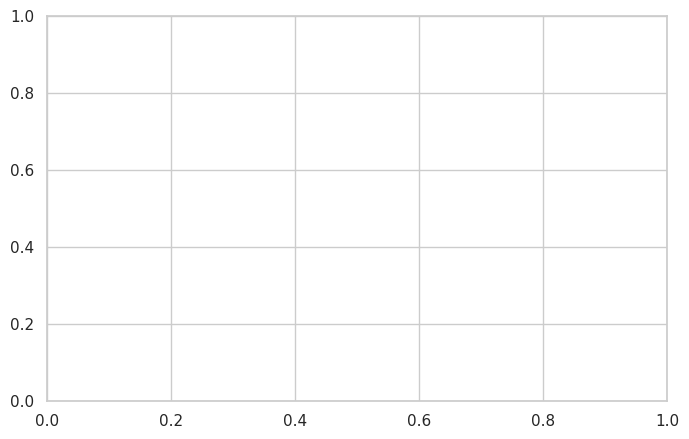

In [8]:
import seaborn as sns
import numpy as np
import pandas as pd
import yasa
import matplotlib.pyplot as plt

# Set global seaborn styling for beautiful, professional plots
sns.set_theme(style="whitegrid", palette="muted")
stage_names = ['Wake', 'N1', 'N2', 'Deep', 'REM']

fig, ax = plt.subplots(figsize=(8, 5))
stage_counts = pd.Series(y).value_counts().sort_index()

sns.barplot(x=stage_names, y=stage_counts.values, ax=ax, palette="viridis")
ax.set_title("Sleep Stage Distribution (Training Data)", fontsize=14, fontweight='bold')
ax.set_ylabel("Number of 30-second Epochs", fontsize=12)
ax.set_xlabel("Sleep Stage", fontsize=12)

for i, v in enumerate(stage_counts.values):
    ax.text(i, v + (v*0.02), str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

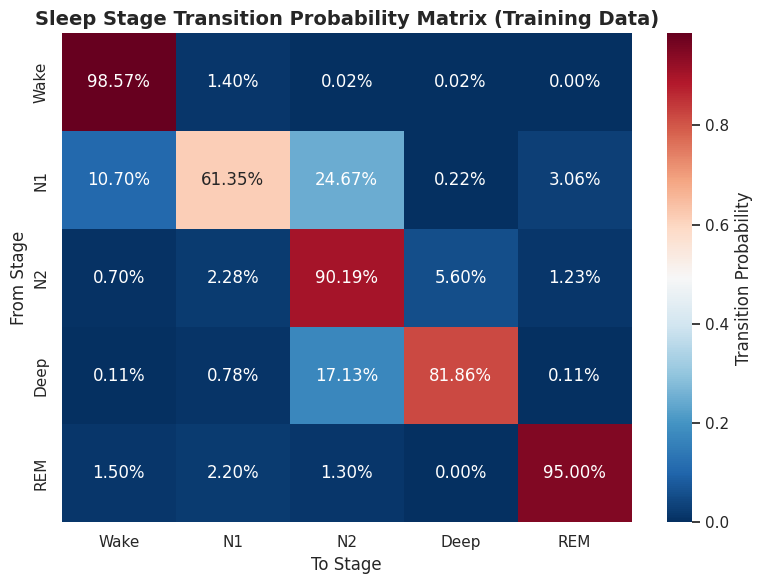

In [54]:
transitions = np.zeros((5, 5))
for i in range(len(y) - 1):
    current_stage = int(y[i])
    next_stage = int(y[i+1])
    transitions[current_stage, next_stage] += 1

row_sums = transitions.sum(axis=1, keepdims=True)
transition_probs = np.divide(transitions, row_sums, out=np.zeros_like(transitions), where=row_sums!=0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(transition_probs, annot=True, fmt=".2%", cmap="RdBu_r",
            xticklabels=stage_names, yticklabels=stage_names, cbar_kws={'label': 'Transition Probability'})
ax.set_title("Sleep Stage Transition Probability Matrix (Training Data)", fontsize=14, fontweight='bold')
ax.set_ylabel("From Stage", fontsize=12)
ax.set_xlabel("To Stage", fontsize=12)
plt.tight_layout()
plt.show()

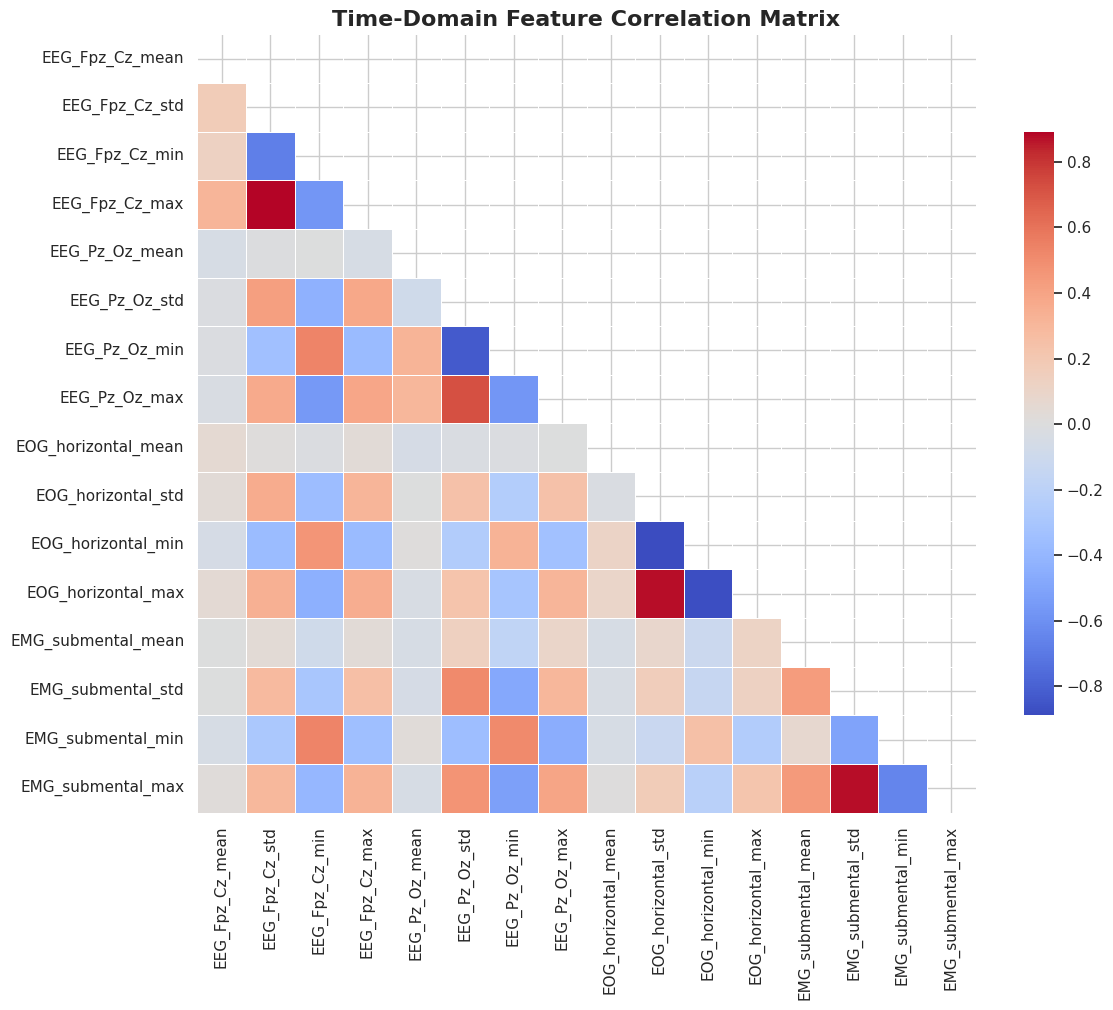

In [55]:
feat_df_only = features_df.drop(columns=['time', 'subject_id', 'label'])
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = feat_df_only.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap="coolwarm", center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .75})
ax.set_title("Time-Domain Feature Correlation Matrix", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

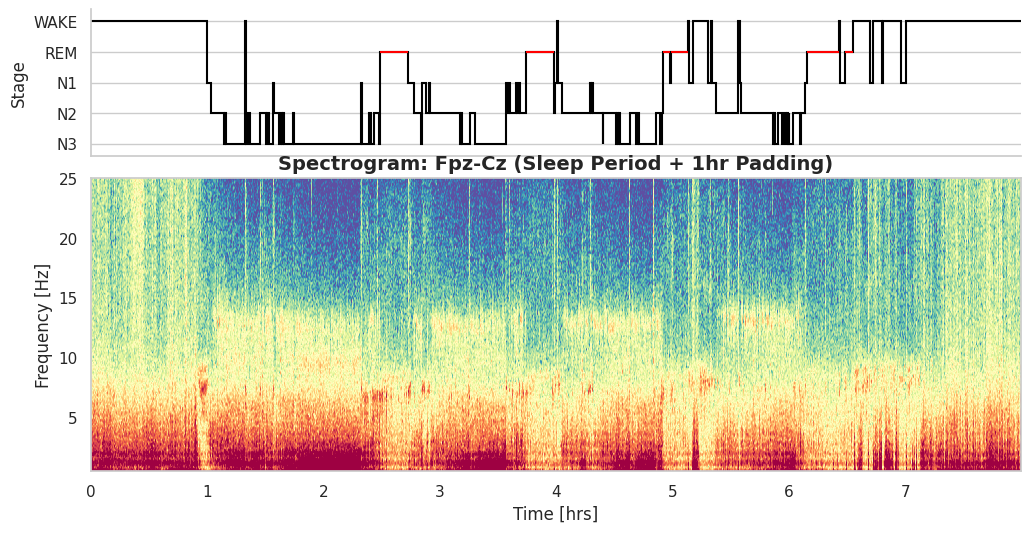

In [57]:
ch_idx = raw1.ch_names.index('EEG Fpz-Cz')
raw_data = raw1.get_data()[ch_idx, :]
sf = raw1.info['sfreq']

# Extract hypnogram for just the first subject (subject_id == 0)
hypno_raw1 = features_df[features_df['subject_id'] == 0]['label'].values

# Find the actual sleep period (any stage > 0)
sleep_indices = np.where(hypno_raw1 > 0)[0]

if len(sleep_indices) > 0:
# 1 hour padding = 60 mins * 2 epochs/min = 120 epochs
    padding_epochs = 120
    start_epoch = max(0, sleep_indices[0] - padding_epochs)
    end_epoch = min(len(hypno_raw1), sleep_indices[-1] + padding_epochs)

# Trim the hypnogram
    hypno_trimmed = hypno_raw1[start_epoch:end_epoch]

# Trim the raw data based on samples (1 epoch = 30 seconds)
    start_sample = int(start_epoch * 30 * sf)
    end_sample = int(end_epoch * 30 * sf)
    raw_data_trimmed = raw_data[start_sample:end_sample]
else:
    hypno_trimmed = hypno_raw1
    raw_data_trimmed = raw_data
hypno_up = yasa.hypno_upsample_to_data(hypno=hypno_trimmed, sf_hypno=(1/30), data=raw_data_trimmed, sf_data=sf)
fig = yasa.plot_spectrogram(raw_data_trimmed, sf, hypno=hypno_up, cmap='Spectral_r')
plt.title("Spectrogram: Fpz-Cz (Sleep Period + 1hr Padding)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Extraction + Model

In [10]:
from sklearn.model_selection import GroupKFold
import mne
import numpy as np
import pandas as pd

subject_features = []
common_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']

raw_configs = [
    ('SC4001E0-PSG.edf', 'SC4001EC-Hypnogram.edf'),
    ('SC4161E0-PSG.edf', 'SC4161EC-Hypnogram.edf'),
    ('SC4011E0-PSG.edf', 'SC4011EH-Hypnogram.edf'),
    ('ST7011J0-PSG.edf', 'ST7011JP-Hypnogram.edf'),
    ('ST7012J0-PSG.edf', 'ST7012JP-Hypnogram.edf'),
    ('ST7122J0-PSG.edf', 'ST7122JE-Hypnogram.edf'),
]

for subj_idx, (psg_file, hyp_file) in enumerate(raw_configs):
    # Epoch each subject individually from scratch to safely track IDs
    r = mne.io.read_raw_edf(f'{project_destination}/{psg_file}', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'), preload=True, verbose=False)
    r.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})
    ann = mne.read_annotations(f'{project_destination}/{hyp_file}')
    r.set_annotations(ann)
    r.pick(common_channels)
    r.resample(100.0, npad='auto')

    subj_epochs = mne.make_fixed_length_epochs(r, duration=30.0, preload=True, verbose=False)
    X_data = subj_epochs.get_data()
    epoch_midpoints = np.arange(len(subj_epochs)) * 30.0 + 15.0
    epoch_labels = [stage_at_time(t, r.annotations) for t in epoch_midpoints]

    for idx, epoch in enumerate(X_data):
        lbl = epoch_labels[idx]
        if lbl in class_map:
            row = {'time': epoch_midpoints[idx], 'subject_id': subj_idx, 'label': class_map[lbl]}
            for ch_idx, ch_name in enumerate(subj_epochs.ch_names):
                data = epoch[ch_idx]
                prefix = ch_name.replace(' ', '_').replace('-', '_')
                row[f'{prefix}_mean'] = data.mean()
                row[f'{prefix}_std'] = data.std()
                row[f'{prefix}_min'] = data.min()
                row[f'{prefix}_max'] = data.max()
            subject_features.append(row)

features_df = pd.DataFrame(subject_features)
TRAINING_FEATURE_COLUMNS = features_df.drop(columns=['time', 'subject_id', 'label']).columns.tolist()

X = features_df[TRAINING_FEATURE_COLUMNS]
y = features_df['label'].values
groups = features_df['subject_id'].values

gkf = GroupKFold(n_splits=5)
cv_model = XGBClassifier(eval_metric='mlogloss', random_state=42)

scores = cross_val_score(cv_model, X, y, cv=gkf, groups=groups, scoring='accuracy')
print('Leakage-Free GroupKFold CV scores: ', scores)
print('Mean CV accuracy: ', scores.mean())

cv_model.fit(X, y)


Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Leakage-Free GroupKFold CV scores:  [0.89114918 0.93433962 0.79359023 0.69230769 0.70176322]
Mean CV accuracy:  0.8026299902047807


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Testing

In [11]:
# Testing model on new data set (test_raw1 and test_ann1)
def evaluate_test_raw(test_raw_obj, model):
    # Fix: explicitly pick the common channels so extra channels (like 'Marker') don't cause feature mismatch
    common_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']
    test_raw_obj.pick(common_channels)

    test_epochs = mne.make_fixed_length_epochs(test_raw_obj, duration=30.0, preload=True)
    test_epoch_midpoints = np.arange(len(test_epochs)) * 30.0 + 15.0
    test_labels = [stage_at_time(t, test_raw_obj.annotations) for t in test_epoch_midpoints]

    test_valid_mask = np.array([lbl in class_map for lbl in test_labels])
    test_X_data = test_epochs.get_data()[test_valid_mask]
    test_y_true = np.array([class_map[lbl] for lbl in test_labels if lbl in class_map], dtype=int)
    test_times = test_epoch_midpoints[test_valid_mask]

    test_feature_rows = []
    for idx, epoch in enumerate(test_X_data):
        row = {'time': test_times[idx]}
        for ch_idx, ch_name in enumerate(test_epochs.ch_names):
            data = epoch[ch_idx]
            prefix = ch_name.replace(' ', '_').replace('-', '_')
            row[f'{prefix}_mean'] = data.mean()
            row[f'{prefix}_std'] = data.std()
            row[f'{prefix}_min'] = data.min()
            row[f'{prefix}_max'] = data.max()
        test_feature_rows.append(row)

    test_features_df = pd.DataFrame(test_feature_rows)
    test_y_pred = model.predict(test_features_df.drop(columns=['time']))
    test_accuracy = accuracy_score(test_y_true, test_y_pred)
    return test_accuracy, test_epochs, test_y_true, test_y_pred, test_X_data

test_accuracy_sc, test_epochs, test_y, test_y_pred, test_X_data = evaluate_test_raw(test_raw1, cv_model)
print(f'SC Test Accuracy: {test_accuracy_sc:.4f}')

test_accuracy_st, _, test_y_st, _, test_X_data_st = evaluate_test_raw(test_raw2, cv_model)
print(f'ST Test Accuracy: {test_accuracy_st:.4f}')

Not setting metadata
2670 matching events found
No baseline correction applied
0 projection items activated
Loading data for 2670 events and 3000 original time points ...
0 bad epochs dropped
SC Test Accuracy: 0.8124
Not setting metadata
958 matching events found
No baseline correction applied
0 projection items activated
Loading data for 958 events and 3000 original time points ...
0 bad epochs dropped
ST Test Accuracy: 0.6362


In [50]:
!pip install shap captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.5 MB/s eta 0:00:00


Calculating SHAP values for XGBoost...


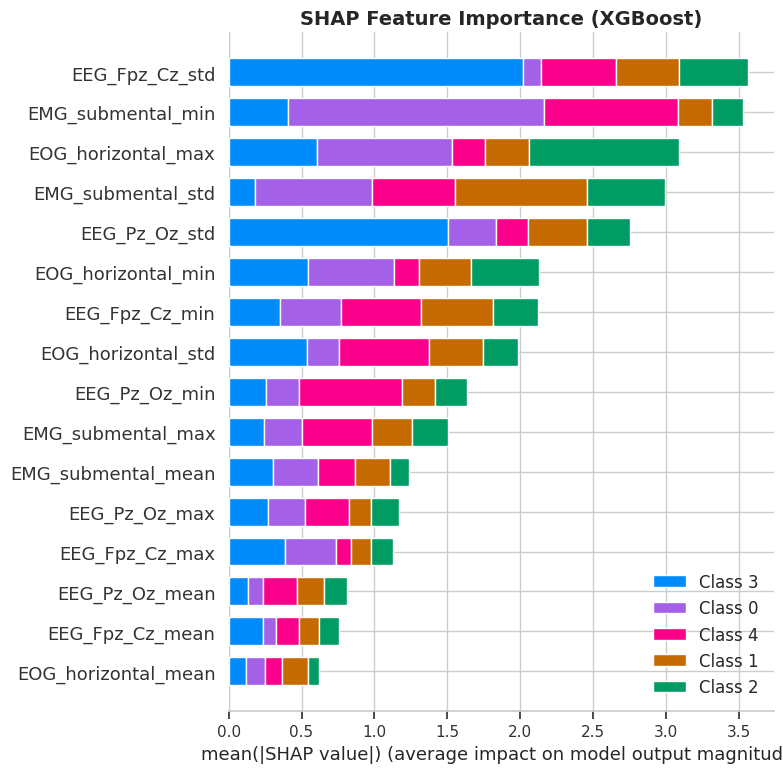

In [51]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(cv_model)

shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (XGBoost)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## Hypnogram

(2670,)
(2670,)


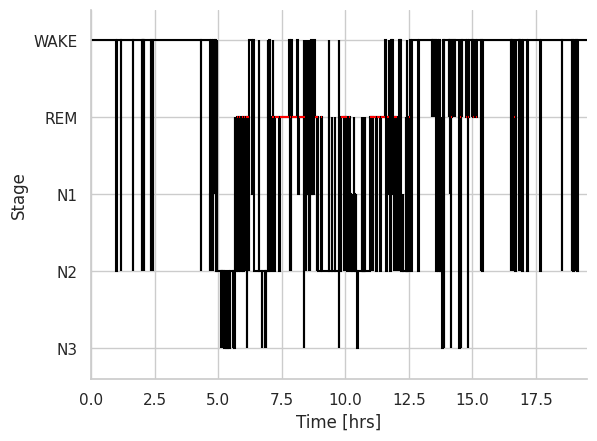

In [21]:
# ------------------------------------------HYPNOGRAM CREATION-------------------------------------
print(test_y_pred.shape)
print(test_y.shape)

# Find the actual sleep period (any stage > 0)
sleep_indices = np.where(test_y_pred > 0)[0]

if len(sleep_indices) > 0:
    # 1 hour padding = 60 mins * 2 epochs/min = 120 epochs
    padding_epochs = 120
    start_epoch = max(0, sleep_indices[0] - padding_epochs)
    end_epoch = min(len(test_y_pred), sleep_indices[-1] + padding_epochs)
    test_y_pred_trimmed = test_y_pred[start_epoch:end_epoch]
else:
    test_y_pred_trimmed = test_y_pred

# plot correct hypnogram
hyp2 = Hypnogram.from_integers(test_y_pred_trimmed)
hyp2.plot_hypnogram()
plt.savefig("SampleHypnogram.png")
plt.show()


### Full Hypnogram and Epoch Detail
This visualization shows the complete sleep progression across the entire recording, paired with a detailed view of a single epoch.

## Confusion Matrix

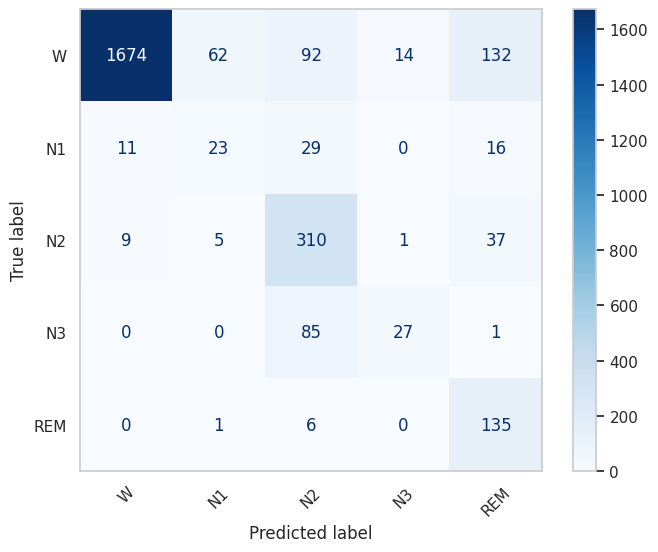

In [15]:
# ------------------------------------------CONFUSION MATRIX-------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_y, test_y_pred)
classes = np.unique(np.concatenate([test_y, test_y_pred]))

stage_names = {
    0: 'W',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'REM'
}
labels = [stage_names[c] for c in classes]

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

## turn off grid
ax.grid(False)

plt.show()

    Using multitaper spectrum estimation with 7 DPSS windows


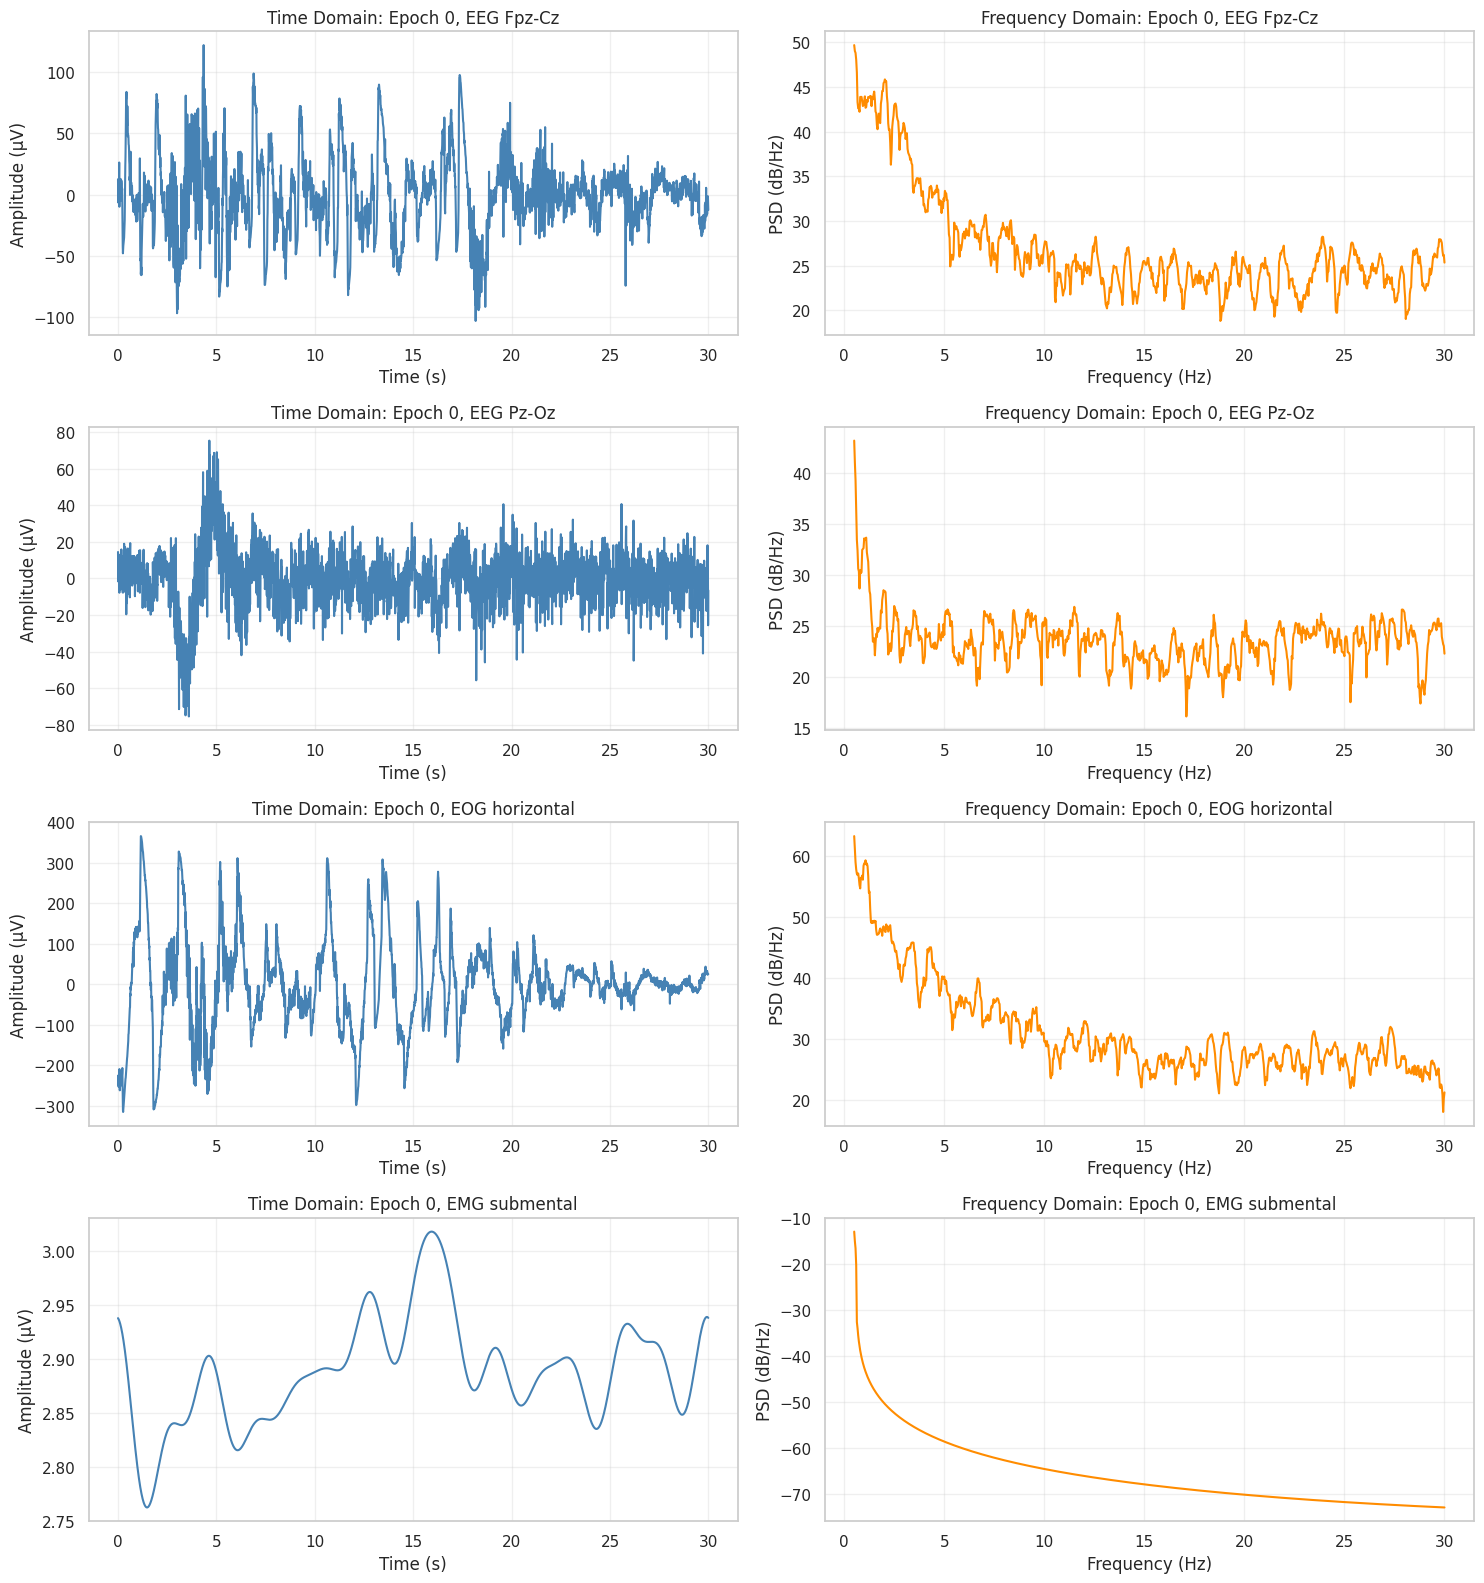

In [31]:
import matplotlib.pyplot as plt
import numpy as np

epoch_idx = 0
test_psd = test_epochs.compute_psd(fmin=0.5, fmax=30, picks=['eeg', 'eog', 'emg'])
ch_names = test_psd.ch_names
n_channels = len(ch_names)

# Create subplots: n_channels rows, 2 columns
fig, axes = plt.subplots(n_channels, 2, figsize=(15, 4 * n_channels))

for i, ch_name in enumerate(ch_names):
    time_data = test_epochs.get_data(picks=ch_name)[epoch_idx, 0, :]
    times = test_epochs.times

    # 2. Frequency Domain Data (After PSD)
    psd_data = test_psd.get_data(picks=ch_name)[epoch_idx, 0, :]
    freqs = test_psd.freqs

    ax1 = axes[i, 0] if n_channels > 1 else axes[0]
    ax2 = axes[i, 1] if n_channels > 1 else axes[1]

    # Plot Time Domain
    ax1.plot(times, time_data * 1e6, color='steelblue') # Convert to uV for readability
    ax1.set_title(f"Time Domain: Epoch {epoch_idx}, {ch_name}")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude (µV)")
    ax1.grid(True, alpha=0.3)

    psd_db = 10 * np.log10(psd_data * 1e12) # Scale appropriately for uV^2/Hz
    ax2.plot(freqs, psd_db, color='darkorange')
    ax2.set_title(f"Frequency Domain: Epoch {epoch_idx}, {ch_name}")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("PSD (dB/Hz)")
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SleepHybridNet(nn.Module):
    def __init__(self, num_channels=4, num_classes=5, d_model=64, nhead=4, num_layers=2):
        super(SleepHybridNet, self).__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            # extract high-frequency local features
            nn.Conv1d(in_channels=num_channels, out_channels=32, kernel_size=50, stride=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            #  extract broader contextual features
            nn.Conv1d(in_channels=32, out_channels=d_model, kernel_size=8, stride=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
        )

        # The Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=0.2,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        # x shape: (B, 4, 3000)

        # Extract features
        features = self.cnn(x)
        # features shape: (B, d_model, Sequence_Length)

        features = features.permute(0, 2, 1)

        transformer_out = self.transformer(features)

        pooled = torch.mean(transformer_out, dim=1)

        out = self.classifier(pooled)
        return out

model = SleepHybridNet()
print(model)

SleepHybridNet(
  (cnn): Sequential(
    (0): Conv1d(4, 32, kernel_size=(50,), stride=(5,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(8,), stride=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm

In [17]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# NOTE: The training metrics below reflect in-sample performance only as this
# current PyTorch split lacks subject-aware cross-validation (GroupKFold).

X_train_raw = epochs.get_data()

epoch_mids = np.arange(len(epochs)) * 30.0 + 15.0
correct_labels = [stage_at_time(t, raw.annotations) for t in epoch_mids]

Y_train_raw = np.array([class_map.get(i, i) for i in correct_labels])

valid_mask = [isinstance(lbl, int) for lbl in Y_train_raw]
X_train = X_train_raw[valid_mask]
Y_train = Y_train_raw[valid_mask].astype(int)

B, C, L = X_train.shape
# Transpose and flatten to (B*L, C) so the scaler sees 4 features (the channels)
X_train_reshaped = X_train.transpose(0, 2, 1).reshape(-1, C)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
# Reshape back to (B, C, L)
X_train_scaled = X_train_scaled.reshape(B, L, C).transpose(0, 2, 1)
X_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_tensor = torch.tensor(Y_train, dtype=torch.long)

dataset = TensorDataset(X_tensor, Y_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

Using device: cuda


In [18]:
import torch.optim as optim

model = SleepHybridNet(num_channels=4, num_classes=5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs_to_train = 30

print("Starting training...")
for epoch in range(epochs_to_train):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_Y in train_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_Y.size(0)
        correct += (predicted == batch_Y).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs_to_train} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

Starting training...
Epoch 1/30 - Loss: 0.6497 - Accuracy: 77.72%
Epoch 2/30 - Loss: 0.4834 - Accuracy: 83.21%
Epoch 3/30 - Loss: 0.4530 - Accuracy: 84.24%
Epoch 4/30 - Loss: 0.4397 - Accuracy: 84.76%
Epoch 5/30 - Loss: 0.4146 - Accuracy: 85.25%
Epoch 6/30 - Loss: 0.4066 - Accuracy: 85.54%
Epoch 7/30 - Loss: 0.4033 - Accuracy: 85.60%
Epoch 8/30 - Loss: 0.3912 - Accuracy: 85.78%
Epoch 9/30 - Loss: 0.3811 - Accuracy: 86.41%
Epoch 10/30 - Loss: 0.3683 - Accuracy: 86.87%
Epoch 11/30 - Loss: 0.3613 - Accuracy: 87.09%
Epoch 12/30 - Loss: 0.3599 - Accuracy: 87.19%
Epoch 13/30 - Loss: 0.3623 - Accuracy: 87.05%
Epoch 14/30 - Loss: 0.3432 - Accuracy: 87.51%
Epoch 15/30 - Loss: 0.3384 - Accuracy: 88.20%
Epoch 16/30 - Loss: 0.3385 - Accuracy: 88.06%
Epoch 17/30 - Loss: 0.3260 - Accuracy: 88.03%
Epoch 18/30 - Loss: 0.3283 - Accuracy: 88.06%
Epoch 19/30 - Loss: 0.3114 - Accuracy: 88.60%
Epoch 20/30 - Loss: 0.3157 - Accuracy: 88.40%
Epoch 21/30 - Loss: 0.3033 - Accuracy: 88.90%
Epoch 22/30 - Loss: 0.

Starting Out-of-Sample Evaluation...
Test Loss: 0.3413
Test Accuracy: 89.55%

Classification Report:
              precision    recall  f1-score   support

    Wake (0)       0.99      0.95      0.97      1974
      N1 (1)       0.13      0.18      0.15        79
      N2 (2)       0.75      0.93      0.83       362
    Deep (3)       0.96      0.48      0.64       113
     REM (4)       0.67      0.80      0.73       142

    accuracy                           0.90      2670
   macro avg       0.70      0.67      0.66      2670
weighted avg       0.92      0.90      0.90      2670



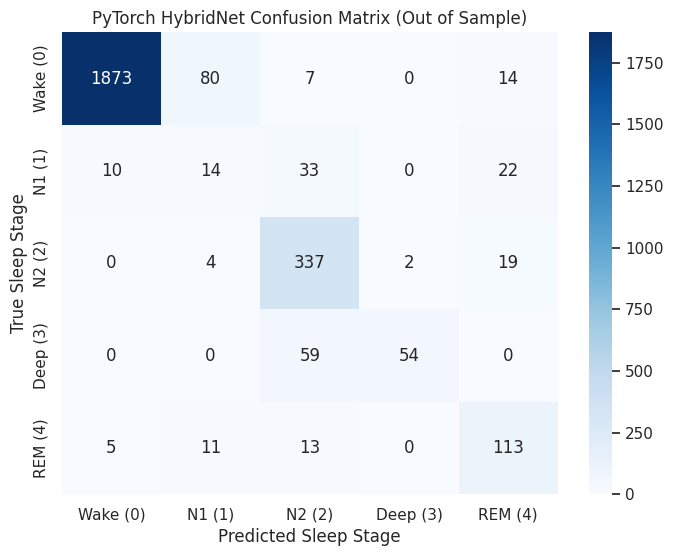

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

B_test, C_test, L_test = test_X_data.shape

# Match the reshaping done during training
X_test_reshaped = test_X_data.transpose(0, 2, 1).reshape(-1, C_test)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(B_test, L_test, C_test).transpose(0, 2, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(test_y, dtype=torch.long)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
test_loss = 0.0
all_preds = []
all_targets = []

print("Starting Out-of-Sample Evaluation...")

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)
        test_loss += loss.item() * batch_X.size(0)

        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_Y.cpu().numpy())

avg_test_loss = test_loss / len(test_dataset)
test_acc = 100 * sum([p == t for p, t in zip(all_preds, all_targets)]) / len(all_targets)

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%\n")

print("Classification Report:")
target_names = ['Wake (0)', 'N1 (1)', 'N2 (2)', 'Deep (3)', 'REM (4)']
print(classification_report(all_targets, all_preds, target_names=target_names))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('PyTorch HybridNet Confusion Matrix (Out of Sample)')
plt.ylabel('True Sleep Stage')
plt.xlabel('Predicted Sleep Stage')
plt.show()


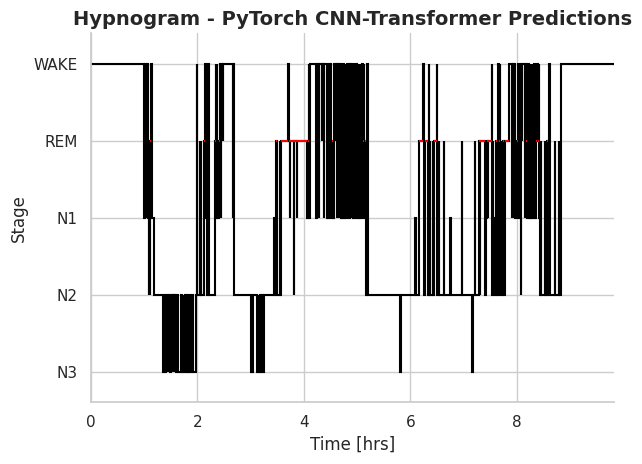

In [22]:
from yasa import Hypnogram
import matplotlib.pyplot as plt
import numpy as np

# Find the actual sleep period (any stage > 0)
preds_array = np.array(all_preds)
sleep_indices = np.where(preds_array > 0)[0]

if len(sleep_indices) > 0:
    # 1 hour padding = 60 mins * 2 epochs/min = 120 epochs
    padding_epochs = 120
    start_epoch = max(0, sleep_indices[0] - padding_epochs)
    end_epoch = min(len(preds_array), sleep_indices[-1] + padding_epochs)
    all_preds_trimmed = preds_array[start_epoch:end_epoch]
else:
    all_preds_trimmed = preds_array

# Create and plot the hypnogram using PyTorch CNN-Transformer predictions
hyp_pytorch = Hypnogram.from_integers(all_preds_trimmed)

hyp_pytorch.plot_hypnogram()
plt.title("Hypnogram - PyTorch CNN-Transformer Predictions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


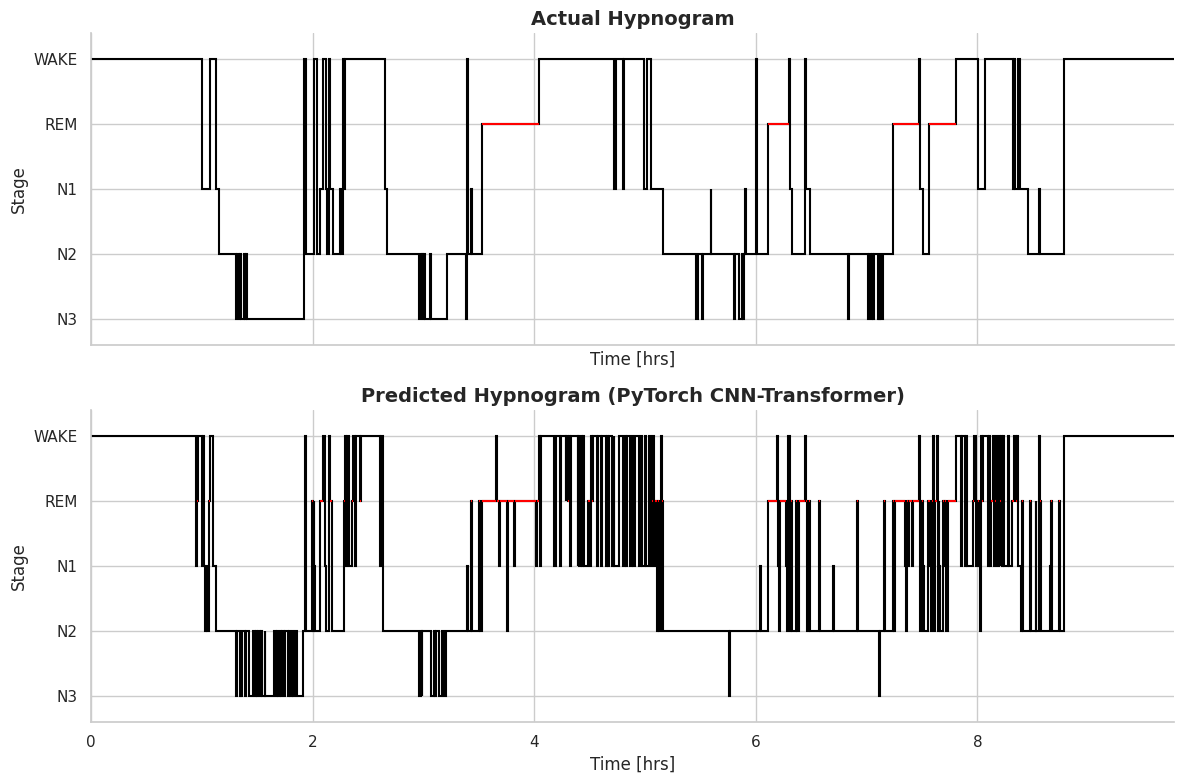

In [23]:
from yasa import Hypnogram
import matplotlib.pyplot as plt
import numpy as np

targets_array = np.array(all_targets)
preds_array = np.array(all_preds)

sleep_indices = np.where(targets_array > 0)[0]

if len(sleep_indices) > 0:
    padding_epochs = 120
    start_epoch = max(0, sleep_indices[0] - padding_epochs)
    end_epoch = min(len(targets_array), sleep_indices[-1] + padding_epochs)
    actuals_trimmed = targets_array[start_epoch:end_epoch]
    preds_trimmed = preds_array[start_epoch:end_epoch]
else:
    actuals_trimmed = targets_array
    preds_trimmed = preds_array

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

hyp_actual = Hypnogram.from_integers(actuals_trimmed)
hyp_actual.plot_hypnogram(ax=axes[0])
axes[0].set_title("Actual Hypnogram", fontsize=14, fontweight='bold')

hyp_pred = Hypnogram.from_integers(preds_trimmed)
hyp_pred.plot_hypnogram(ax=axes[1])
axes[1].set_title("Predicted Hypnogram (PyTorch CNN-Transformer)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [37]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Extracting subject-aware epochs...")
X_list, y_list, group_list = [], [], []

for subj_idx, (psg_file, hyp_file) in enumerate(raw_configs):
    r = mne.io.read_raw_edf(f'{project_destination}/{psg_file}', exclude=('Resp oro-nasal', 'Temp rectal', 'Event marker'), preload=True, verbose=False)
    r.set_channel_types({'EOG horizontal': 'eog', 'EMG submental': 'emg'})
    ann = mne.read_annotations(f'{project_destination}/{hyp_file}')
    r.set_annotations(ann)
    r.pick(common_channels)
    r.resample(100.0, npad='auto')

    subj_epochs = mne.make_fixed_length_epochs(r, duration=30.0, preload=True, verbose=False)
    X_data = subj_epochs.get_data()
    epoch_midpoints = np.arange(len(subj_epochs)) * 30.0 + 15.0
    epoch_labels = [stage_at_time(t, r.annotations) for t in epoch_midpoints]

    for idx, epoch in enumerate(X_data):
        lbl = epoch_labels[idx]
        if lbl in class_map:
            X_list.append(epoch)
            y_list.append(class_map[lbl])
            group_list.append(subj_idx) # Track the subject ID!

X_all = np.array(X_list)
y_all = np.array(y_list)
groups_all = np.array(group_list)

# Handle Class Imbalance
classes = np.unique(y_all)
# Computes weights inversely proportional to class frequencies
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_all)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Calculated Class Weights: {weights}")

#  GroupKFold Training Loop with Early Stopping
gkf = GroupKFold(n_splits=5)
epochs_to_train = 30


for fold, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups_all)):
    print(f"\n================ Fold {fold + 1} ================")

    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    scaler = StandardScaler()
    B_tr, C, L = X_train.shape
    X_train_reshaped = X_train.transpose(0, 2, 1).reshape(-1, C)
    X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(B_tr, L, C).transpose(0, 2, 1)

    B_val = X_val.shape[0]
    X_val_reshaped = X_val.transpose(0, 2, 1).reshape(-1, C)
    X_val_scaled = scaler.transform(X_val_reshaped).reshape(B_val, L, C).transpose(0, 2, 1)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32),
                                            torch.tensor(y_train, dtype=torch.long)),
                              batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),
                                          torch.tensor(y_val, dtype=torch.long)),
                            batch_size=64, shuffle=False)

    model = SleepHybridNet(num_channels=4, num_classes=5).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs_to_train):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                val_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()

        avg_train_loss = train_loss / train_total
        avg_val_loss = val_loss / val_total
        val_acc = 100 * val_correct / val_total

        print(f"Epoch {epoch+1:02d}/{epochs_to_train} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")


Using device: cuda
Extracting subject-aware epochs...
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Calculated Class Weights: [0.37523136 4.86899563 0.78108581 2.49720045 2.22777223]

================ Fold 1 ================
Epoch 01/30 | Train Loss: 0.8834 | Val Loss: 0.3177 | Val Acc: 88.37%
Epoch 02/30 | Train Loss: 0.6480 | Val Loss: 0.3153 | Val Acc: 89.90%
Epoch 03/30 | Train Loss: 0.6242 | Val Loss: 0.2951 | Val Acc: 89.65%
Epoch 04/30 | Train Loss: 0.5794 | Val Loss: 0.3106 | Val Acc: 87.37%
Epoch 05/30 | Train Loss: 0.5303 | Val Loss: 0.2997 | Val Acc: 88.87%
Epoch 06/30 | Train L